# Exploratory data analysis — Medical RAG system

This notebook explores the **mtsamples.csv** dataset of 5000+ clinical transcriptions.  


In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from src.preprocessing import load_data, clean_text, chunk_documents, get_token_lengths

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

## 1. Data loading & overview

In [3]:
df = load_data("../data/mtsamples.csv")
print(f"Dataset shape: {df.shape}")
print(f"Unique specialties: {df['medical_specialty'].nunique()}")
print()
df.info()

Dataset shape: (4966, 6)
Unique specialties: 40

<class 'pandas.DataFrame'>
RangeIndex: 4966 entries, 0 to 4965
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         4966 non-null   int64
 1   description        4966 non-null   str  
 2   medical_specialty  4966 non-null   str  
 3   sample_name        4966 non-null   str  
 4   transcription      4966 non-null   str  
 5   keywords           3898 non-null   str  
dtypes: int64(1), str(5)
memory usage: 232.9 KB


In [4]:
# Missing values per column
print("Missing values:")
print(df.isna().sum())
print()
df.head(3)

Missing values:
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription           0
keywords             1068
dtype: int64



,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with complaint of allergies.,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female presents with complaint of allergies. She used to have allergies when s...","allergy / immunology, allergic rhinitis, allergies, asthma, nasal sprays, rhinitis, nasal, erythematous, allegra, sp..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climbing stairs, difficulty with airline seats, tying shoes, used to public...","bariatrics, laparoscopic gastric bypass, weight loss programs, gastric bypass, atkin's diet, weight watcher's, body ..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC today. He is a very pleasant gentleman who is 42 years old, 344 pound...","bariatrics, laparoscopic gastric bypass, heart attacks, body weight, pulmonary embolism, potential complications, sl..."


## 2. Token-length analysis 

We count tokens per raw transcription to understand document sizes and determine an appropriate **chunk size** for the RAG pipeline.

The distribution is right-skewed because most transcriptions are short-to-medium, but a long tail extends to 3489 tokens. 52% of documents are under 500 tokens, 48% are longer, so nearly half the dataset needs chunking. 10% exceed 1000 tokens, but they are rather irrelevant since these are the long surgical reports, discharge summaries, etc.

Since the embedding model (MiniLM) has a 512-token window, I chose 500-character chunks with 50-character overlap to ensure each chunk fits within the model's capacity while preserving context at boundaries.

Token length statistics:
count    4966.0
mean      553.0
std       362.0
min         3.0
25%       289.2
50%       485.0
75%       731.0
90%      1005.0
95%      1207.5
max      3489.0
Name: transcription, dtype: float64


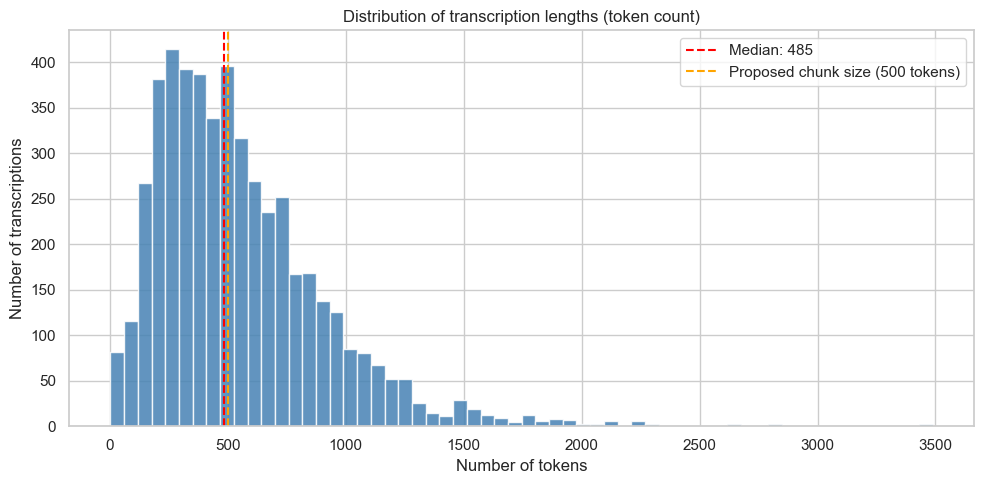

In [5]:
token_lengths = get_token_lengths(df["transcription"])

stats = token_lengths.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
print("Token length statistics:")
print(stats.round(1))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(token_lengths, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(token_lengths.median(), color="red", linestyle="--", label=f"Median: {token_lengths.median():.0f}")
ax.axvline(500, color="orange", linestyle="--", label="Proposed chunk size (500 tokens)")
ax.set_xlabel("Number of tokens")
ax.set_ylabel("Number of transcriptions")
ax.set_title("Distribution of transcription lengths (token count)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Token length after preprocessing

Preprocessing nearly halves the token count which helps in ensuring that the system will not halucinate later on. Average drops from 547 to 296 tokens, the cleaned distribution shifting significantly to the left. Maximum token-length drops from 2299 to 1246, even the longest documents shrinking substantially.

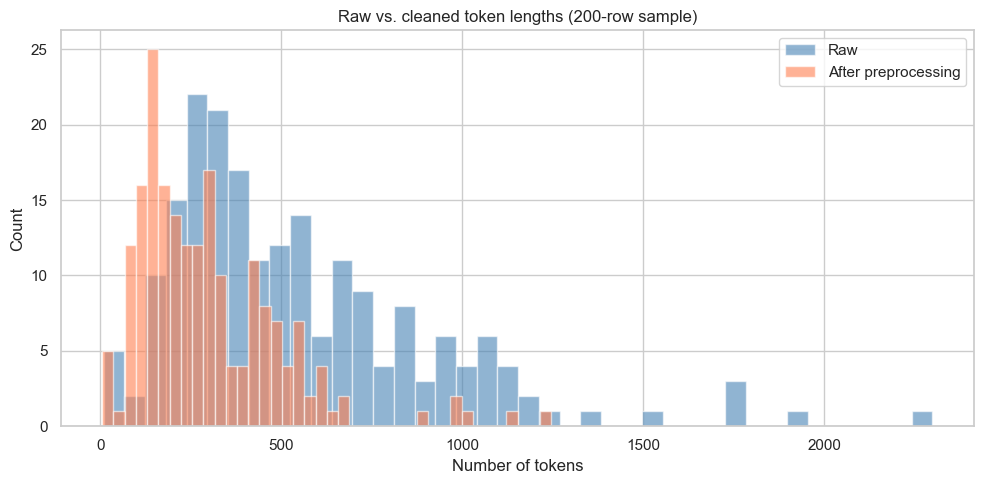

Token reduction after preprocessing: 45.8%


In [6]:
sample = df.sample(n=200, random_state=42)

raw_lengths = get_token_lengths(sample["transcription"])
cleaned_lengths = get_token_lengths(sample["transcription"].apply(clean_text))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(raw_lengths, bins=40, alpha=0.6, label="Raw", color="steelblue", edgecolor="white")
ax.hist(cleaned_lengths, bins=40, alpha=0.6, label="After preprocessing", color="coral", edgecolor="white")
ax.set_xlabel("Number of tokens")
ax.set_ylabel("Count")
ax.set_title("Raw vs. cleaned token lengths (200-row sample)")
ax.legend()
plt.tight_layout()
plt.show()

reduction = (1 - cleaned_lengths.sum() / raw_lengths.sum()) * 100
print(f"Token reduction after preprocessing: {reduction:.1f}%")

## 4. Medical specialty distribution

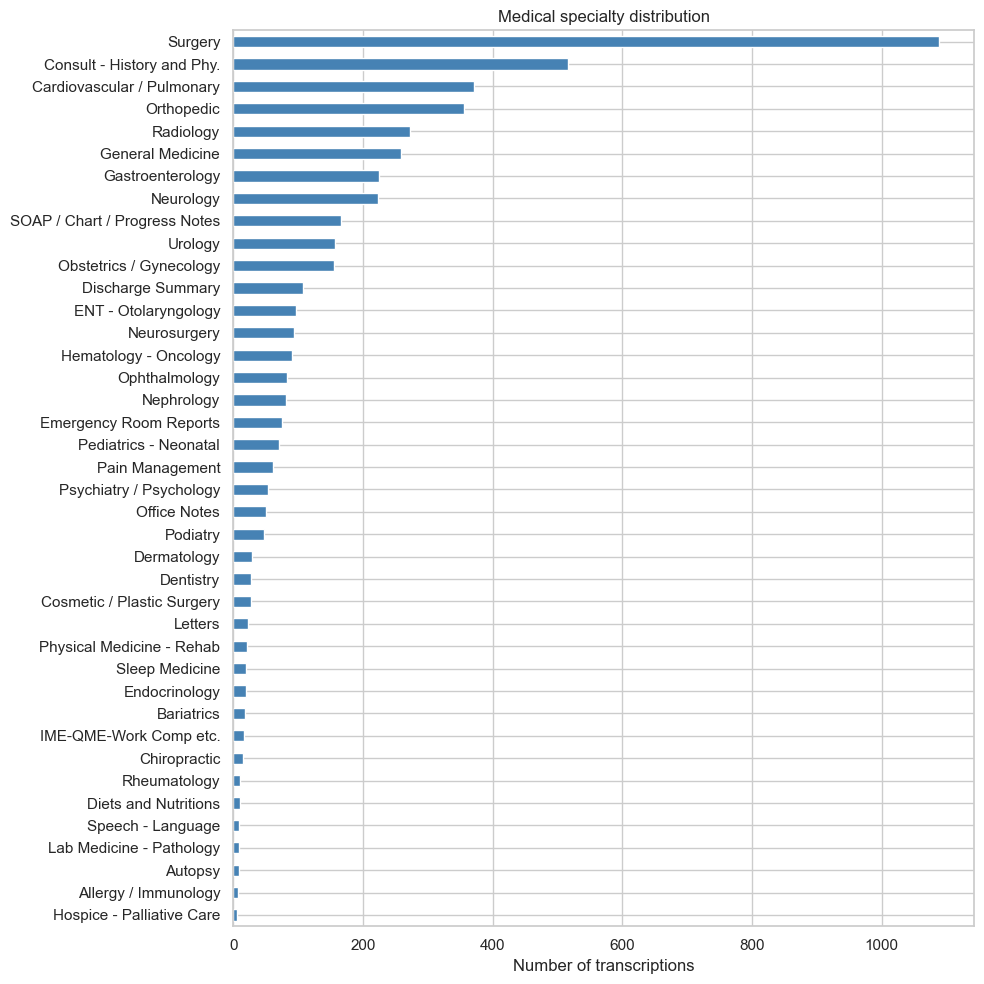

In [7]:
specialty_counts = df["medical_specialty"].value_counts()

fig, ax = plt.subplots(figsize=(10, 10))
specialty_counts.plot.barh(ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Number of transcriptions")
ax.set_ylabel("")
ax.set_title("Medical specialty distribution")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Chunking strategy

In [ ]:
long_row = df.loc[token_lengths.idxmax()]
print(f"Longest transcription: {token_lengths.max()} tokens, specialty: {long_row['medical_specialty']}")
print(f"Raw character length: {len(long_row['transcription'])}\n")

demo_chunks = chunk_documents(df.loc[[token_lengths.idxmax()]], chunk_size=500, chunk_overlap=50)
print(f"Produced {len(demo_chunks)} chunks from this single document.\n")

for i, chunk in enumerate(demo_chunks[:3]):
    print(f"--- Chunk {i} ({len(chunk['text'])} chars) ---")
    print(chunk["text"][:200] + "...")
    print()

Longest transcription: 3489 tokens, specialty: Letters
Raw character length: 18425

Produced 48 chunks from this single document.

--- Chunk 0 (313 chars) ---
DATE OF INJURY : October 4, 2000,DATE OF EXAMINATION : September 5, 2003,EXAMINING PHYSICIAN : X Y, MD,Prior to the beginning of the examination, it is explained to the examinee that this examination ...

--- Chunk 1 (462 chars) ---
. It is explained to the examinee that the traditional doctor-patient relationship does not apply to this examination, and that a written report will be provided to the agency requesting this examinat...

--- Chunk 2 (481 chars) ---
. Abc is a 52-year-old self-employed, independent consultant for DEMILEE-USA. He is also a mechanical engineer. He reports that he was injured in a motor vehicle accident that occurred in October 4, 2...



## 6. Save preprocessed chunks

In [ ]:
chunks = chunk_documents(df, chunk_size=500, chunk_overlap=50)
print(f"Total chunks produced: {len(chunks)}")
print(f"From {len(df)} transcriptions")
print(f"Average chunks per document: {len(chunks) / len(df):.1f}")

with open("../data/chunks.pkl", "wb") as f:
    pickle.dump(chunks, f)

print(f"\nSaved to data/chunks.pkl")

Total chunks produced: 38838
From 4966 transcriptions
Average chunks per document: 7.8

Saved to data/chunks.pkl
